# NOTE: there needs to be a data folder with the training and testing datasets. I didn't include them in the repo coz they were too heavy

In [88]:
import torch
import pandas as pd
from torch import nn, optim
from torchvision import transforms
from torch.utils.data import Dataset, random_split, DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## For the bonus task, I yanked the Dataset class and dataloaders from the base task. I removed some transforms on labels though.

In [89]:
class AutoEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 36),
        nn.ReLU(),
        nn.Linear(36, 18)
    )
    self.decoder = nn.Sequential(
        nn.Linear(18, 36),
        nn.ReLU(),
        nn.Linear(36, 64),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.ReLU(),
        nn.Linear(128, 28*28),
        nn.Sigmoid(),
        nn.Unflatten(1, (1, 28, 28))
    )

  def forward(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

In [90]:
class FashionDataset(Dataset):
  def __init__(self, data, transform=None):
    self.transform = transform
    self.y = data.iloc[:, 0].values
    self.x = data.iloc[:, 1:].values.astype('uint8').reshape(-1, 28, 28) # Can have extra param for b/w

  def __len__(self):
    return self.x.shape[0]

  def __getitem__(self, idx):
    image = self.x[idx]
    if self.transform:
      image = self.transform(image)
    return image, self.y[idx]

def normalize_and_tensor(mean, std):
  transform = transforms.Compose([
      transforms.ToTensor(),
      # transforms.Normalize((mean,), (std,)),
      # Found out that sigmoid already converts it into range of 0-1
      # so normalizing on top of that would cause weird values
  ])
  return transform

In [91]:
model = AutoEncoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [92]:
train_data_raw = pd.read_csv('data/fashion-mnist_train.csv')

data = train_data_raw.iloc[:, 1:].values / 255.0
mean = data.mean()
std = data.std()
transform = normalize_and_tensor(mean, std)

train_data = FashionDataset(train_data_raw, transform=transform)

train_data, val_data = random_split(train_data, [int(len(train_data) * 0.85), int(len(train_data) * 0.15)])

train_data_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_data_loader = DataLoader(val_data, batch_size=64, shuffle=False)

In [93]:
epochs = 20
train_outputs = []
train_losses = []
train_avg_losses = []
val_outputs = []
val_losses = []
val_avg_losses = []

In [94]:
for e in range(epochs):
  model.train()
  train_current_loss = 0
  for img, _ in train_data_loader:
    img = img.to(device)
    output = model(img)
    loss = criterion(output, img)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_current_loss += loss.item()

  train_avg_losses.append(train_current_loss / len(train_data_loader))
  train_outputs.append((e, img, output))
  print(f'Epoch: {e+1} // Loss: {train_current_loss / len(train_data_loader)}')

  model.eval()
  val_current_loss = 0

  with torch.inference_mode():
    for img, _ in val_data_loader:
      img = img.to(device)
      output = model(img)
      loss = criterion(output, img)

      val_losses.append(loss.item())
      val_current_loss += loss.item()

    val_avg_losses.append(val_current_loss / len(val_data_loader))
    val_outputs.append((e, img, output))

Epoch: 1 // Loss: 0.0453018520256432
Epoch: 2 // Loss: 0.02503656434220083
Epoch: 3 // Loss: 0.023095965497616392
Epoch: 4 // Loss: 0.021469421630989353
Epoch: 5 // Loss: 0.020625601829949256
Epoch: 6 // Loss: 0.01970685487951957
Epoch: 7 // Loss: 0.019055645291224926
Epoch: 8 // Loss: 0.018528853781483928
Epoch: 9 // Loss: 0.01809884942460389
Epoch: 10 // Loss: 0.017545148770008213
Epoch: 11 // Loss: 0.017099153816026905
Epoch: 12 // Loss: 0.016670590272428027
Epoch: 13 // Loss: 0.016372232741139914
Epoch: 14 // Loss: 0.01608724649317815
Epoch: 15 // Loss: 0.01582481095116291
Epoch: 16 // Loss: 0.015641555080244052
Epoch: 17 // Loss: 0.015391393603203138
Epoch: 18 // Loss: 0.015199621770077547
Epoch: 19 // Loss: 0.014982000149908
Epoch: 20 // Loss: 0.01472513116615704


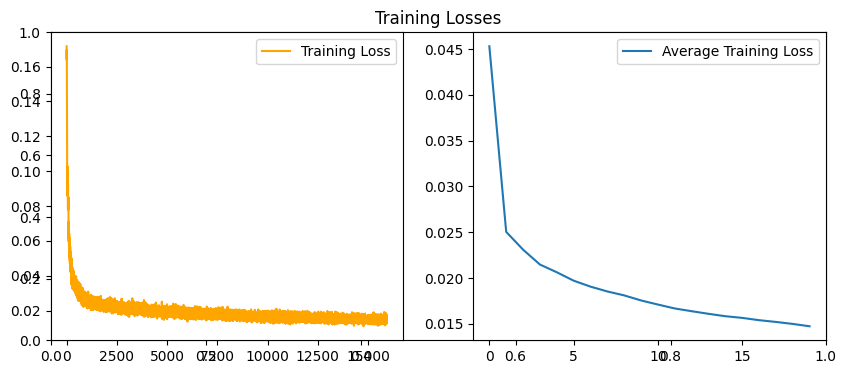

In [95]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 4))
plt.title('Training Losses')

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='orange')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_avg_losses, label='Average Training Loss')
plt.legend()

plt.show()

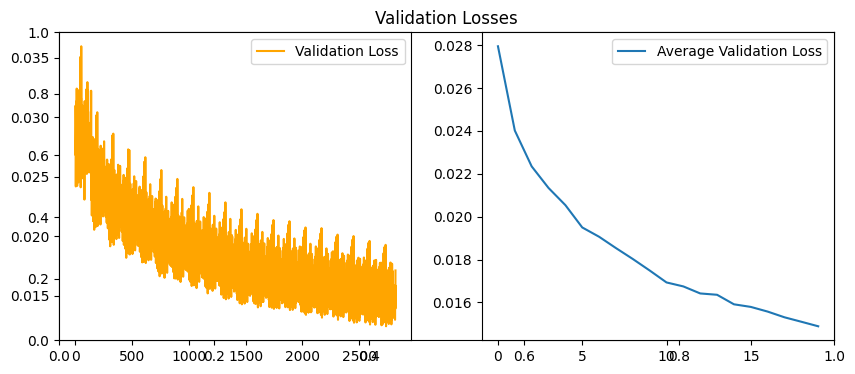

In [96]:
plt.figure(figsize=(10, 4))
plt.title('Validation Losses')

plt.subplot(1, 2, 1)
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_avg_losses, label='Average Validation Loss')
plt.legend()

plt.show()

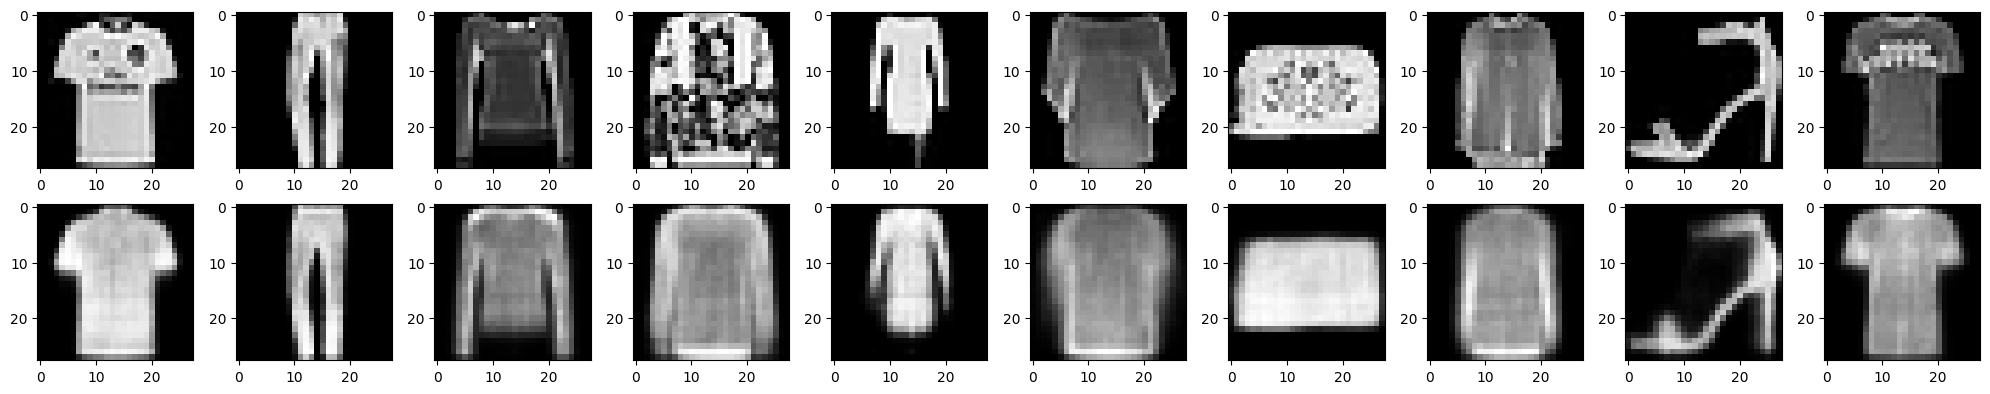

In [97]:
model.eval()
test_data_raw = pd.read_csv('data/fashion-mnist_test.csv')
test_data = FashionDataset(test_data_raw, transform=transform)
test_data_loader = DataLoader(test_data, batch_size=64, shuffle=False)
results = []

with torch.inference_mode():
  for img, _ in test_data_loader:
    img = img.to(device)
    output = model(img)

    results.append((img, output))

img, output = results[0]
fig, axes = plt.subplots(2, 10, figsize=(20, 4))

for i in range(10):
  og = img[i].reshape(28, 28)
  new = output[i].reshape(28, 28)

  axes[0, i].imshow(og, cmap='gray')
  axes[1, i].imshow(new, cmap='gray')

plt.tight_layout()
plt.show()